# DrivAer Bandwidth Comparisons

This notebook compares DrivAer CPU multithread bandwidth from `results/drivaer.csv`. It draws every available JuNe/NeoN strategy family, even when the counterpart is missing.

It also compares DrivAer GPU bandwidth for JuNe and NeoN on H200.


In [43]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent

DATA_CSV = ROOT / "results" / "drivaer.csv"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
OUT_FIG = FIG_DIR / "drivaer_cpu_multithread_bandwidth_june_vs_neon.svg"
OUT_GPU_BANDWIDTH_FIG = FIG_DIR / "drivaer_gpu_bandwidth_june_vs_neon.svg"

sns.set_theme(style="whitegrid", context="paper")


In [44]:
raw = pd.read_csv(DATA_CSV)
cpu = raw[
    (raw["case"] == "DrivAer")
    & (raw["executor"].str.upper() == "CPU")
    & (pd.to_numeric(raw["threads"], errors="coerce") > 1)
].copy()
cpu["threads"] = pd.to_numeric(cpu["threads"], errors="raise").astype(int)
cpu["time_us"] = pd.to_numeric(cpu["time_us"], errors="raise")
cpu["time_ms"] = cpu["time_us"] / 1e3
cpu["nnz"] = pd.to_numeric(cpu["nnz"], errors="raise")
cpu["bandwidth_gbs"] = cpu["nnz"] * 24 / (cpu["time_ms"] * 1_000_000)

family_map = {
    "Cell-Based": "Cell-based",
    "Fused Cell-Based": "Cell-based",
    "Face-Based": "Face-based",
    "Fused Face-Based": "Face-based",
    "Global Face-Based": "Global Face-based",
}
variant_map = {
    ("JuNe", "Cell-Based"): "JuNe",
    ("JuNe", "Face-Based"): "JuNe",
    ("JuNe", "Global Face-Based"): "JuNe",
    ("NeoN", "Cell-Based"): "NeoN",
    ("NeoN", "Face-Based"): "NeoN",
    ("NeoN", "Global Face-Based"): "NeoN",
    ("NeoN", "Fused Cell-Based"): "NeoN Fused",
    ("NeoN", "Fused Face-Based"): "NeoN Fused",
}
plot_df = cpu.copy()
plot_df["Family"] = plot_df["strategy"].map(family_map)
plot_df["Implementation"] = plot_df.apply(
    lambda row: variant_map.get((row["julia_or_neon"], row["strategy"])),
    axis=1,
)
plot_df = plot_df[plot_df["Family"].notna() & plot_df["Implementation"].notna()].copy()
plot_df = (
    plot_df.groupby(["node", "threads", "Family", "Implementation"], as_index=False)
    .agg(bandwidth_gbs=("bandwidth_gbs", "mean"), runs=("bandwidth_gbs", "size"))
    .sort_values(["node", "Family", "Implementation", "threads"])
)
plot_df.head()


,node,threads,Family,Implementation,bandwidth_gbs,runs
0,gpu-nvidia-h100,2,Cell-based,JuNe,1.459866,3
6,gpu-nvidia-h100,4,Cell-based,JuNe,1.724934,6
12,gpu-nvidia-h100,8,Cell-based,JuNe,2.616520,6
18,gpu-nvidia-h100,16,Cell-based,JuNe,2.924211,6
24,gpu-nvidia-h100,32,Cell-based,JuNe,3.383114,6


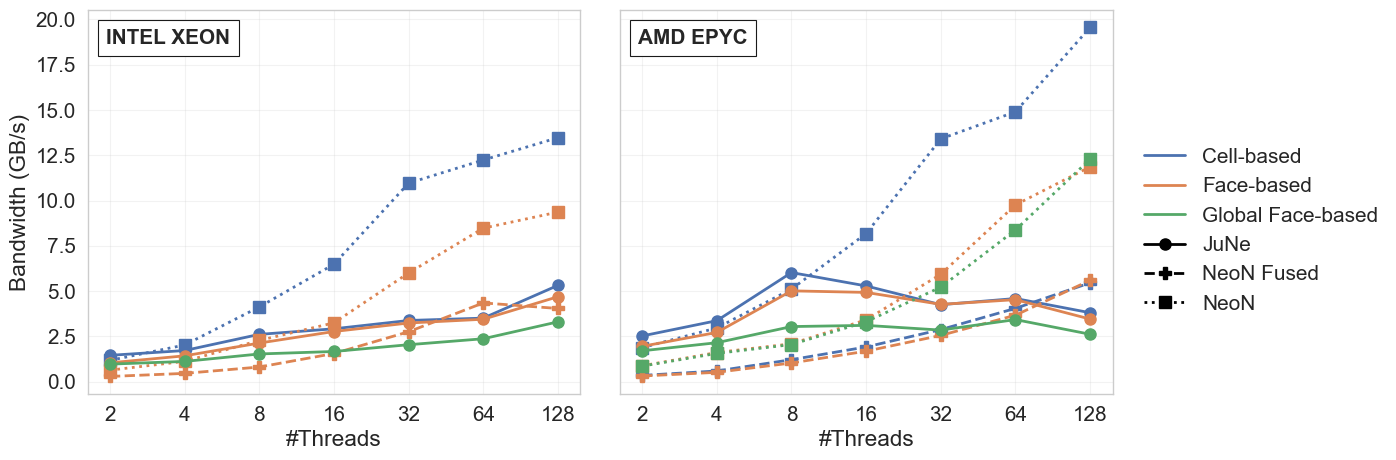

Wrote figures/drivaer_cpu_multithread_bandwidth_june_vs_neon.svg


In [45]:
family_order = ["Cell-based", "Face-based", "Global Face-based"]
implementation_order = ["JuNe", "NeoN Fused", "NeoN"]
threads = sorted(plot_df["threads"].unique())
nodes = sorted(plot_df["node"].unique())
palette = dict(zip(family_order, sns.color_palette("deep", n_colors=len(family_order))))
markers = {"JuNe": "o", "NeoN Fused": "P", "NeoN": "s"}
linestyles = {"JuNe": "-", "NeoN Fused": "--", "NeoN": ":"}

with sns.plotting_context("paper", font_scale=1.7):
    fig, axes = plt.subplots(1, len(nodes), figsize=(12.5, 4.8), sharey=True)
    if len(nodes) == 1:
        axes = [axes]

    for ax, node in zip(axes, nodes):
        node_df = plot_df[plot_df["node"] == node]
        for family in family_order:
            for implementation in implementation_order:
                line_df = node_df[
                    (node_df["Family"] == family)
                    & (node_df["Implementation"] == implementation)
                ]
                if line_df.empty:
                    continue
                ax.plot(
                    line_df["threads"],
                    line_df["bandwidth_gbs"],
                    color=palette[family],
                    marker=markers[implementation],
                    linestyle=linestyles[implementation],
                    linewidth=2.0,
                    markersize=8,
                )
        ax.set_xscale("log", base=2)
        ax.set_xticks(threads)
        ax.set_xticklabels([str(thread) for thread in threads])
        ax.grid(True, which="both", alpha=0.25)
        ax.set_xlabel("#Threads")
        label = "INTEL XEON" if "h100" in node.lower() else "AMD EPYC"
        at = AnchoredText(
            label,
            loc="upper left",
            bbox_transform=ax.transAxes,
            frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"], "weight": "bold"},
        )
        ax.add_artist(at)
    axes[0].set_ylabel("Bandwidth (GB/s)")

    family_handles = [
        Line2D([0], [0], color=palette[family], linewidth=2.0, label=family)
        for family in family_order
    ]
    implementation_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            marker=markers[implementation],
            linestyle=linestyles[implementation],
            linewidth=2.0,
            markersize=8,
            label=implementation,
        )
        for implementation in implementation_order
    ]
    fig.legend(
        handles=family_handles + implementation_handles,
        loc="center left",
        bbox_to_anchor=(0.91, 0.5),
        frameon=False,
    )
    fig.subplots_adjust(left=0.08, right=0.9, bottom=0.16, top=0.96, wspace=0.08)
    fig.savefig(OUT_FIG, bbox_inches="tight")
    plt.show()

print(f"Wrote {OUT_FIG.relative_to(ROOT)}")


In [46]:
gpu = raw[
    (raw["case"] == "DrivAer")
    & (raw["executor"].str.upper() == "GPU")
].copy()
gpu["time_us"] = pd.to_numeric(gpu["time_us"], errors="raise")
gpu["time_ms"] = gpu["time_us"] / 1e3
gpu["nnz"] = pd.to_numeric(gpu["nnz"], errors="raise")
gpu["bandwidth_gbs"] = gpu["nnz"] * 24 / (gpu["time_ms"] * 1_000_000)

family_map = {
    "Cell-Based": "Cell-based",
    "Fused Cell-Based": "Cell-based",
    "Face-Based": "Face-based",
    "Fused Face-Based": "Face-based",
    "Global Face-Based": "Global Face-based",
}
variant_map = {
    ("JuNe", "Cell-Based"): "JuNe",
    ("JuNe", "Face-Based"): "JuNe",
    ("JuNe", "Global Face-Based"): "JuNe",
    ("NeoN", "Cell-Based"): "NeoN",
    ("NeoN", "Face-Based"): "NeoN",
    ("NeoN", "Global Face-Based"): "NeoN",
    ("NeoN", "Fused Cell-Based"): "NeoN Fused",
    ("NeoN", "Fused Face-Based"): "NeoN Fused",
}
gpu["Family"] = gpu["strategy"].map(family_map)
gpu["Implementation"] = gpu.apply(
    lambda row: variant_map.get((row["julia_or_neon"], row["strategy"])),
    axis=1,
)
gpu_bandwidth = gpu[gpu["Family"].notna() & gpu["Implementation"].notna()].copy()
gpu_bandwidth_mean = (
    gpu_bandwidth.groupby(["Family", "Implementation"], as_index=False)
    .agg(bandwidth_gbs=("bandwidth_gbs", "mean"), runs=("bandwidth_gbs", "size"))
)
gpu_bandwidth_mean


,Family,Implementation,bandwidth_gbs,runs
0,Cell-based,JuNe,208.540878,3
1,Cell-based,NeoN,81.217360,3
2,Cell-based,NeoN Fused,22.954463,3
3,Face-based,JuNe,215.975852,3
4,Face-based,NeoN,46.157661,3
5,Global Face-based,JuNe,205.859015,3
6,Global Face-based,NeoN,53.558126,3


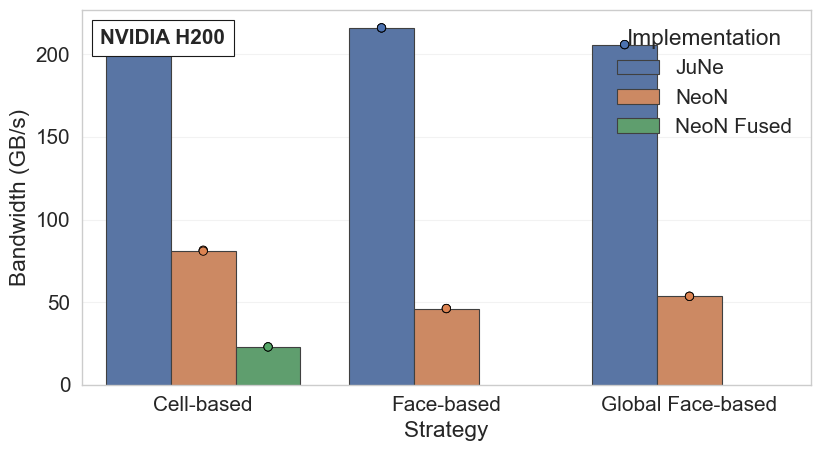

Wrote figures/drivaer_gpu_bandwidth_june_vs_neon.svg


In [47]:
family_order = ["Cell-based", "Face-based", "Global Face-based"]
implementation_order = ["JuNe", "NeoN", "NeoN Fused"]
palette = {"JuNe": "#4c72b0", "NeoN": "#dd8452", "NeoN Fused": "#55a868"}

with sns.plotting_context("paper", font_scale=1.7):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    sns.barplot(
        data=gpu_bandwidth_mean,
        x="Family",
        y="bandwidth_gbs",
        hue="Implementation",
        order=family_order,
        hue_order=implementation_order,
        palette=palette,
        ax=ax,
        edgecolor="0.25",
        linewidth=0.8,
    )
    sns.stripplot(
        data=gpu_bandwidth,
        x="Family",
        y="bandwidth_gbs",
        hue="Implementation",
        order=family_order,
        hue_order=implementation_order,
        palette=palette,
        dodge=True,
        jitter=False,
        size=6,
        marker="o",
        edgecolor="black",
        linewidth=0.6,
        ax=ax,
        legend=False,
    )
    ax.set_xlabel("Strategy")
    ax.set_ylabel("Bandwidth (GB/s)")
    ax.grid(True, axis="y", alpha=0.25)
    at = AnchoredText(
        "NVIDIA H200",
        loc="upper left",
        bbox_transform=ax.transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"], "weight": "bold"},
    )
    ax.add_artist(at)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[: len(implementation_order)], labels[: len(implementation_order)], title="Implementation", frameon=False, loc="upper right")
    fig.tight_layout()
    fig.savefig(OUT_GPU_BANDWIDTH_FIG, bbox_inches="tight")
    plt.show()

print(f"Wrote {OUT_GPU_BANDWIDTH_FIG.relative_to(ROOT)}")
